# Comparing the results of multiple 
This document 

## Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import random

In [2]:
from os import listdir
from os.path import isfile, join


Importing the collected data

In [3]:
#from google.colab import files
#uploaded = files.upload()
#%ls

In [4]:
def plot_time_series(predicted, true, n_training, filename):
  """
  Plot the time series
  """
  plt.figure(figsize=(16,10)) #plotting
  plt.axvline(x=n_training, color="#ffd166", linestyle='-') #size of the training set

  plt.plot(predicted, label='Predicted Price', color="#118ab2") #predicted plot
  plt.plot(true, label='True Price', color="#06d6a0") #actual plot

  plt.title('Time-Series Prediction', fontsize=16)
  plt.xlabel('Time', fontsize=14)
  plt.ylabel('Price', fontsize=14)

  plt.xlim(0)
  plt.legend()
  plt.show()
  plt.savefig(filename) 

## LSTM Model


### Model Definition

In [5]:
class LSTMCustom(nn.Module):
    def __init__(self, num_classes, input_size, hidden_size, num_layers, seq_length):
        super(LSTMCustom, self).__init__()
        self.num_classes = num_classes #number of classes
        self.num_layers = num_layers #number of layers
        self.input_size = input_size #input size
        self.hidden_size = hidden_size #hidden state
        self.seq_length = seq_length #sequence length

        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                          num_layers=num_layers, batch_first=True) #lstm
        self.fc_1 =  nn.Linear(hidden_size, 128) #fully connected 1
        self.fc = nn.Linear(128, num_classes) #fully connected last layer

        self.relu = nn.ReLU()
    
    def forward(self,x):
        h_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) #hidden state
        c_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) #internal state
        # Propagate input through LSTM
        output, (hn, cn) = self.lstm(x, (h_0, c_0)) #lstm with input, hidden, and internal state
        hn = hn.view(-1, self.hidden_size) #reshaping the data for Dense layer next
        out = self.relu(hn)
        out = self.fc_1(out) #first Dense
        out = self.relu(out) #relu
        out = self.fc(out) #Final Output
        return out

Model Parameters

In [6]:
num_epochs = 1000 #1000 epochs
learning_rate = 0.001 #0.001 lr

input_size = 7 #number of features
hidden_size = 7 #number of features in hidden state
num_layers = 1 #number of stacked lstm layers

num_classes = 1 #number of output classes 

In [7]:
criterion = torch.nn.MSELoss()  # mean-squared error for regression

### Training Each Crypto

In [8]:
mm = MinMaxScaler()
ss = StandardScaler()

In [9]:
def train_test_split_tensor(x, y):
  """
  Custom train/test splitting
  TODO: maybe shorten code by using sklearn.preprocessing.train_test_split
  """
  cutoff = round(x.shape[0] * 0.7)

  # split into train and test
  x_train = x[:cutoff, :]
  x_test = x[cutoff:,:]
  y_train = y[:cutoff, :]
  y_test = y[cutoff:, :]

  # convert to tensor
  x_train = Variable(torch.Tensor(x_train))
  x_test = Variable(torch.Tensor(x_test))
  y_train = Variable(torch.Tensor(y_train))
  y_test = Variable(torch.Tensor(y_test)) 
  
  return x_train, x_test, y_train, y_test, cutoff

In [10]:
def process_data(df):

  # shift the prices - shouldn't need if properly pre-processed
  df2 = df.copy(deep=True)
  df['priceUsd'] = df.priceUsd.shift(-1)
  df = df.iloc[1:-1]
  df2 = df2.iloc[1:-1]

  # split into x and y
  x = df.iloc[:, 0:-1]
  y = df2.iloc[:, 0:1]
  #y = df.iloc[:,0:1]
  
  # transform the data
  x_ss = ss.fit_transform(x)
  y_mm = mm.fit_transform(y) 

  # get train and test split and convert to tensors
  x_train, x_test, y_train, y_test, cutoff = train_test_split_tensor(x_ss, y_mm)

  # reshape tensors 
  x_train = torch.reshape(x_train, (x_train.shape[0], 1, x_train.shape[1]))
  x_test = torch.reshape(x_test, (x_test.shape[0], 1, x_test.shape[1])) 

  return x_train, x_test, y_train, y_test, cutoff

In [11]:
def train(df, lstm):
  """
  Train the lstm
  """
  x_train, x_test, y_train, y_test, cutoff = process_data(df)

  for epoch in range(num_epochs):
    outputs = lstm.forward(x_train) #forward pass
    optimizer.zero_grad() #caluclate the gradient, manually setting to 0
  
    # obtain the loss function
    loss = criterion(outputs, y_train)
  
    loss.backward() #calculates the loss of the loss function
  
    optimizer.step() #improve from loss, i.e backprop
    if epoch % 100 == 0:
      print("Epoch: %d, loss: %1.5f" % (epoch, loss.item())) 

  return lstm, cutoff

In [12]:
def classify(predict, direction):
    results = []
    for i in range(len(predict)):
        if (predict[i] > predict[i-1]*1.000):
            results.append("positive")
        elif (predict[i] < predict[i-1]*1.00):
            results.append("negative")
        else:
            results.append("neutral")
    results.append("neutral")
    totalcorrect = 0
    neutralcount = 0
    neutralcorrect = 0
    positivecorrect = 0
    negativecorrect = 0
    positivecount = 0
    negativecount = 0
    neutralprediction = 0
    for i in range(len(predict)):
        if results[i] == "neutral":
            neutralprediction += 1
        if direction[i] == "positive":
            positivecount += 1
        elif direction[i] == "negative":
            negativecount += 1
        elif direction[i] == "neutral":
            neutralcount += 1
        if results[i] == direction[i]:
            totalcorrect += 1
            if results[i] == "negative":
                negativecorrect += 1
            elif results[i] == "positive":
                positivecorrect += 1
            elif results[i] == "neutral":
                neutralcorrect += 1
    #print("number tested: ", len(predict))
    #print("accuracy: ", count/len(predict))
    print("% positive: ", positivecount/len(predict))
    print("% negative: ", negativecount/len(predict))
    print("% neutral: ", neutralcount/len(predict))
    print("positive correct: ", positivecorrect/positivecount)
    print("negative correct: ", negativecorrect/negativecount)
    #print("neutral correct: ", neutralcorrect/neutralcount)
    print("neutral prediction: ", neutralprediction/len(predict))

    return totalcorrect/len(predict)

binance-coinhourly.csv
Epoch: 0, loss: 0.00519
Epoch: 100, loss: 0.00012
Epoch: 200, loss: 0.00001
Epoch: 300, loss: 0.00000
Epoch: 400, loss: 0.00000
Epoch: 500, loss: 0.00000
Epoch: 600, loss: 0.00000
Epoch: 700, loss: 0.00000
Epoch: 800, loss: 0.00000
Epoch: 900, loss: 0.00000
% positive:  0.5184580202548187
% negative:  0.4815419797451813
% neutral:  0.0
positive correct:  0.6887208569628229
negative correct:  0.6886024423337856
neutral prediction:  0.0006533812479581836
0.6886638353479255
    priceUsd  sentiment_positive_reddit  sentiment_positive_twitter  \
0  13.847729                        0.0                    3.170556   
1  13.816300                        0.0                    1.671666   
2  13.791890                        0.0                    1.629437   
3  13.799427                        0.0                    1.696390   
4  13.824445                        0.0                    1.599902   

   sentiment_negative_reddit  sentiment_negative_twitter  \
0             

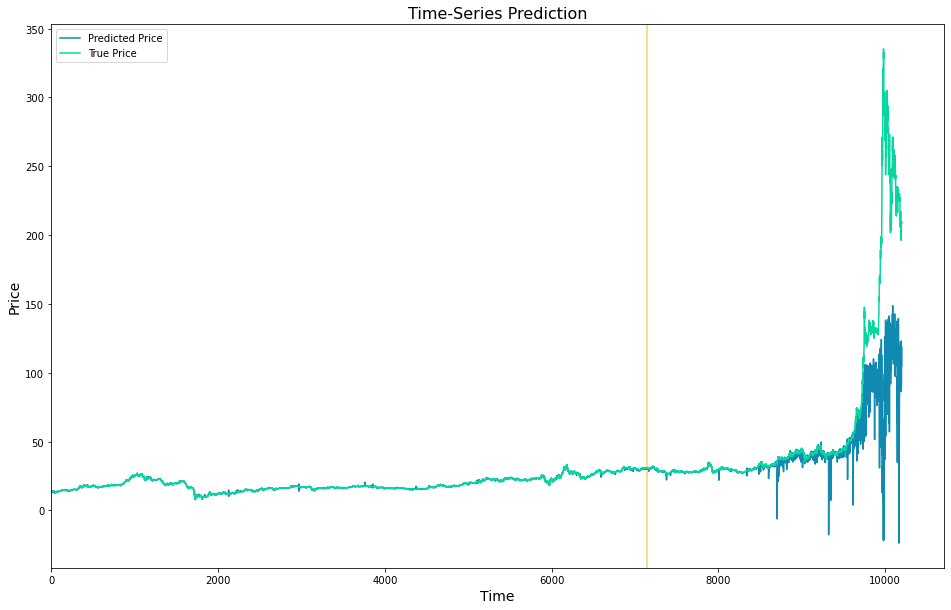

bitcoin-cashhourly.csv
Epoch: 0, loss: 0.09568
Epoch: 100, loss: 0.00165
Epoch: 200, loss: 0.00019
Epoch: 300, loss: 0.00009
Epoch: 400, loss: 0.00005
Epoch: 500, loss: 0.00004
Epoch: 600, loss: 0.00003
Epoch: 700, loss: 0.00003
Epoch: 800, loss: 0.00003
Epoch: 900, loss: 0.00002
% positive:  0.5057170859196342
% negative:  0.4942829140803659
% neutral:  0.0
positive correct:  0.7868217054263565
negative correct:  0.7680105750165235
neutral prediction:  0.0006533812479581836
0.7775236850702385
     priceUsd  sentiment_positive_reddit  sentiment_positive_twitter  \
0  207.047319                   1.710498                    0.832922   
1  205.327925                   0.772305                    0.000000   
2  206.030693                   0.000000                    0.847014   
3  206.114644                   0.000000                    0.000000   
4  206.722380                   0.000000                    0.000000   

   sentiment_negative_reddit  sentiment_negative_twitter  \
0       

<Figure size 432x288 with 0 Axes>

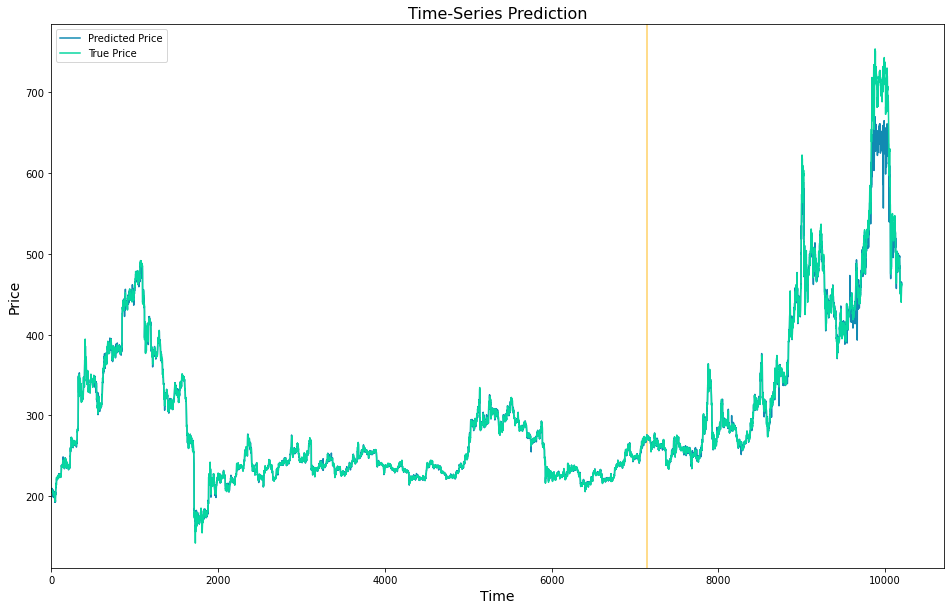

bitcoinhourly.csv
Epoch: 0, loss: 0.03646
Epoch: 100, loss: 0.00081
Epoch: 200, loss: 0.00058
Epoch: 300, loss: 0.00012
Epoch: 400, loss: 0.00004
Epoch: 500, loss: 0.00002
Epoch: 600, loss: 0.00001
Epoch: 700, loss: 0.00001
Epoch: 800, loss: 0.00000
Epoch: 900, loss: 0.00000
% positive:  0.5292388108461287
% negative:  0.4707611891538713
% neutral:  0.0
positive correct:  0.5055555555555555
negative correct:  0.49826509368494104
neutral prediction:  0.0006533812479581836
0.5021234890558641
      priceUsd  sentiment_positive_reddit  sentiment_positive_twitter  \
0  7233.087522                  13.193512                   18.106775   
1  7218.541090                  10.943121                   16.930622   
2  7212.448558                   9.549962                   15.730024   
3  7215.993093                   5.142237                   12.367584   
4  7220.982682                   5.396939                    7.869972   

   sentiment_negative_reddit  sentiment_negative_twitter  \
0     

<Figure size 432x288 with 0 Axes>

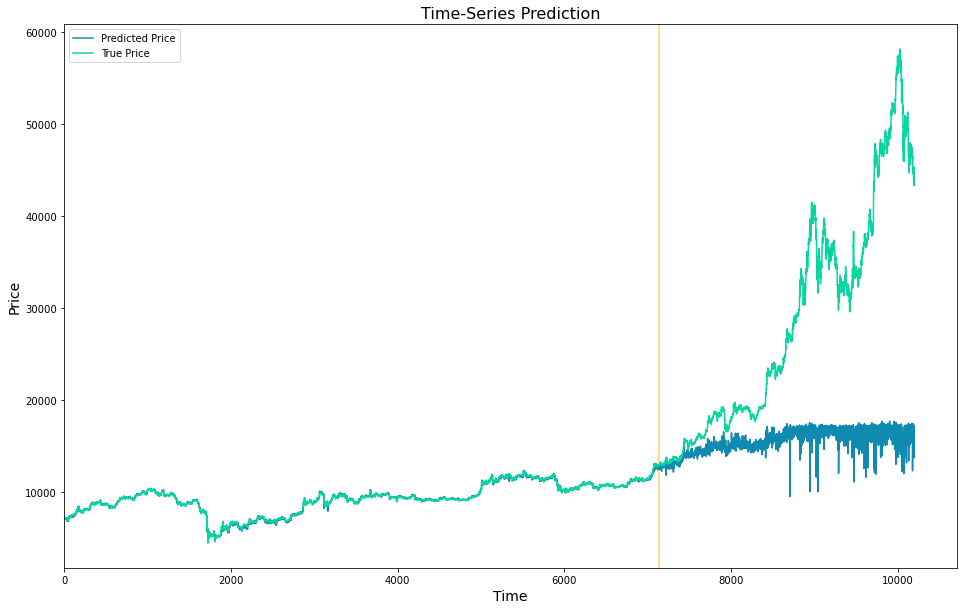

cardanohourly.csv
Epoch: 0, loss: 0.00185
Epoch: 100, loss: 0.00008
Epoch: 200, loss: 0.00001
Epoch: 300, loss: 0.00001
Epoch: 400, loss: 0.00000
Epoch: 500, loss: 0.00000
Epoch: 600, loss: 0.00000
Epoch: 700, loss: 0.00000
Epoch: 800, loss: 0.00000
Epoch: 900, loss: 0.00000
% positive:  0.5099640640313623
% negative:  0.4900359359686377
% neutral:  0.0
positive correct:  0.6707238949391415
negative correct:  0.6613333333333333
neutral prediction:  0.0006533812479581836
0.6661221822933682
   priceUsd  sentiment_positive_reddit  sentiment_positive_twitter  \
0  0.033118                   0.700988                    0.902038   
1  0.033039                   0.000000                    0.000000   
2  0.033029                   0.718183                    0.754052   
3  0.033056                   0.000000                    0.000000   
4  0.033173                   0.000000                    0.000000   

   sentiment_negative_reddit  sentiment_negative_twitter  \
0                   0.000

<Figure size 432x288 with 0 Axes>

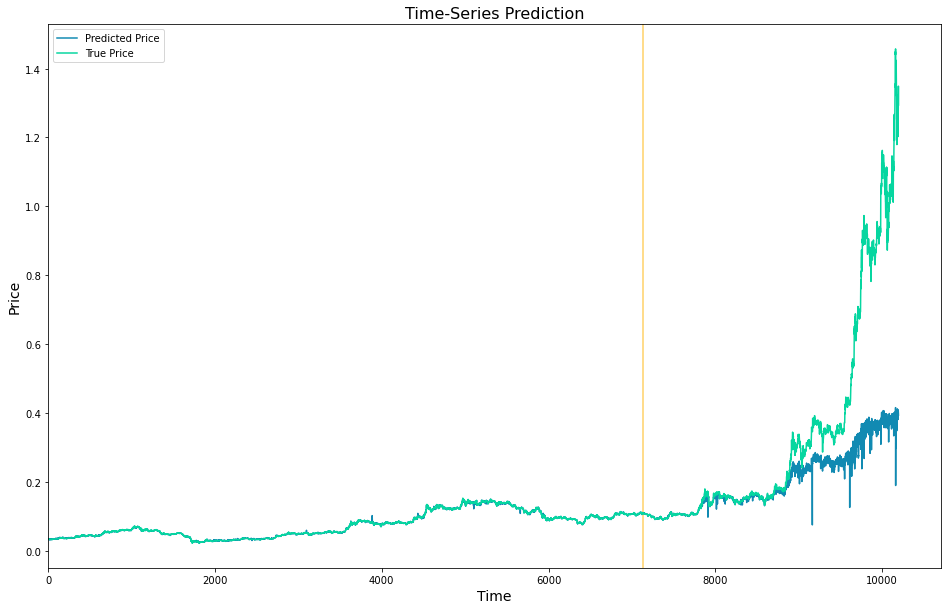

chainlinkhourly.csv
Epoch: 0, loss: 0.03239
Epoch: 100, loss: 0.00126
Epoch: 200, loss: 0.00025
Epoch: 300, loss: 0.00009
Epoch: 400, loss: 0.00005
Epoch: 500, loss: 0.00004
Epoch: 600, loss: 0.00003
Epoch: 700, loss: 0.00003
Epoch: 800, loss: 0.00002
Epoch: 900, loss: 0.00002
% positive:  0.5040836327997387
% negative:  0.49591636720026133
% neutral:  0.0
positive correct:  0.7375243033052495
negative correct:  0.735836627140975
neutral prediction:  0.0006533812479581836
0.736687357072852
   priceUsd  sentiment_positive_reddit  sentiment_positive_twitter  \
0  1.793106                        0.0                    0.000000   
1  1.793276                        0.0                    0.000000   
2  1.797353                        0.0                    0.769444   
3  1.801175                        0.0                    0.000000   
4  1.793562                        0.0                    0.000000   

   sentiment_negative_reddit  sentiment_negative_twitter  \
0                   0.00

<Figure size 432x288 with 0 Axes>

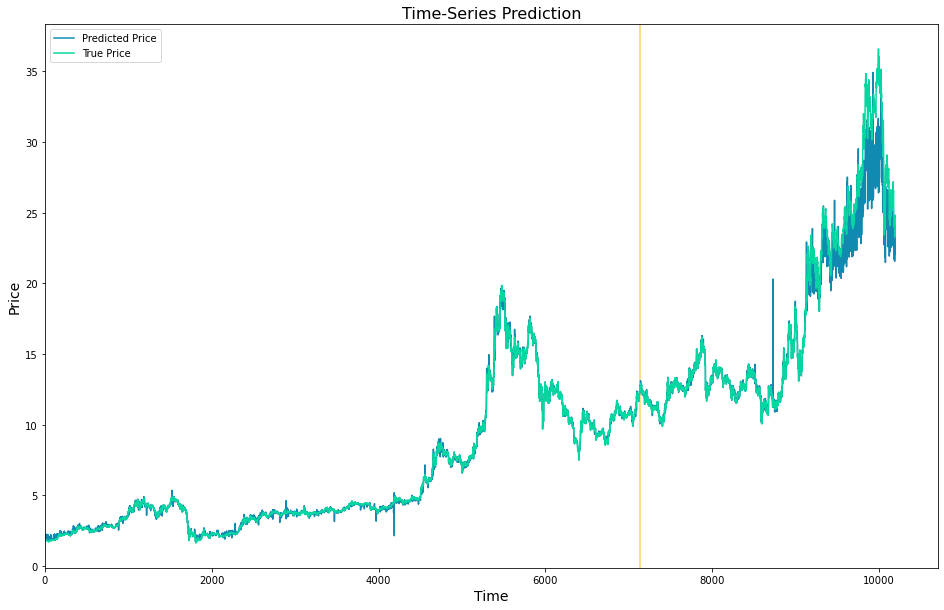

ethereumhourly.csv
Epoch: 0, loss: 0.01693
Epoch: 100, loss: 0.00182
Epoch: 200, loss: 0.00056
Epoch: 300, loss: 0.00006
Epoch: 400, loss: 0.00002
Epoch: 500, loss: 0.00001
Epoch: 600, loss: 0.00001
Epoch: 700, loss: 0.00001
Epoch: 800, loss: 0.00000
Epoch: 900, loss: 0.00000
% positive:  0.519438092126756
% negative:  0.48056190787324404
% neutral:  0.0
positive correct:  0.559748427672956
negative correct:  0.5445275322909585
neutral prediction:  0.0006533812479581836
0.5524338451486442
     priceUsd  sentiment_positive_reddit  sentiment_positive_twitter  \
0  130.732169                   1.704631                    4.820986   
1  130.346569                   2.393945                    4.735292   
2  130.272685                   0.865898                    3.249418   
3  130.378214                   0.931604                    0.000000   
4  130.502785                   0.964787                    0.866252   

   sentiment_negative_reddit  sentiment_negative_twitter  \
0            

<Figure size 432x288 with 0 Axes>

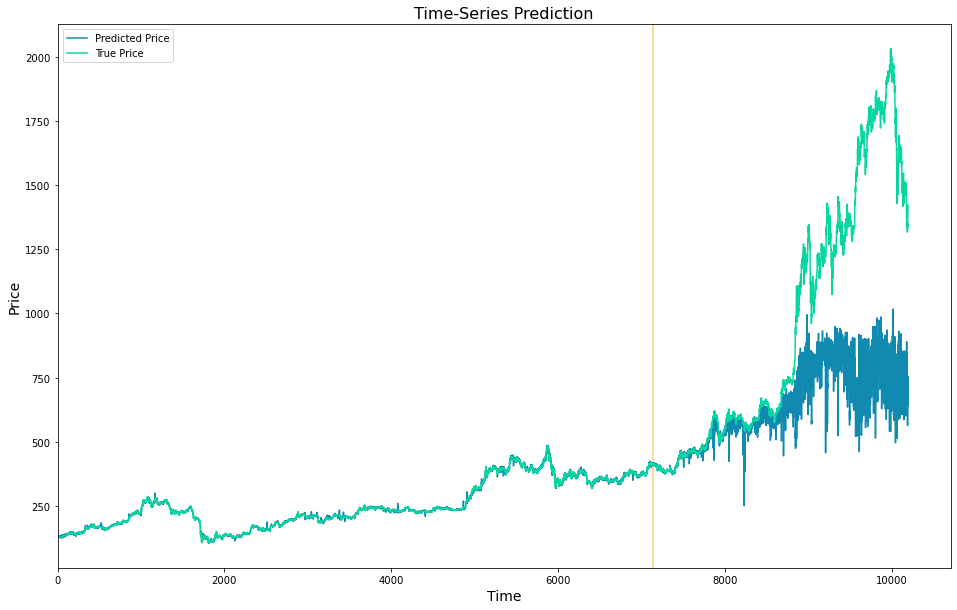

litecoinhourly.csv
Epoch: 0, loss: 0.06668
Epoch: 100, loss: 0.00147
Epoch: 200, loss: 0.00028
Epoch: 300, loss: 0.00005
Epoch: 400, loss: 0.00001
Epoch: 500, loss: 0.00001
Epoch: 600, loss: 0.00001
Epoch: 700, loss: 0.00001
Epoch: 800, loss: 0.00001
Epoch: 900, loss: 0.00001
% positive:  0.5070238484155505
% negative:  0.4929761515844495
% neutral:  0.0
positive correct:  0.6707474226804123
negative correct:  0.6620278330019881
neutral prediction:  0.0006533812479581836
0.6664488729173472
    priceUsd  sentiment_positive_reddit  sentiment_positive_twitter  \
0  41.926050                        0.0                    0.000000   
1  41.586282                        0.0                    2.398006   
2  41.763982                        0.0                    0.000000   
3  41.950505                        0.0                    0.000000   
4  41.743494                        0.0                    0.000000   

   sentiment_negative_reddit  sentiment_negative_twitter  \
0                 

<Figure size 432x288 with 0 Axes>

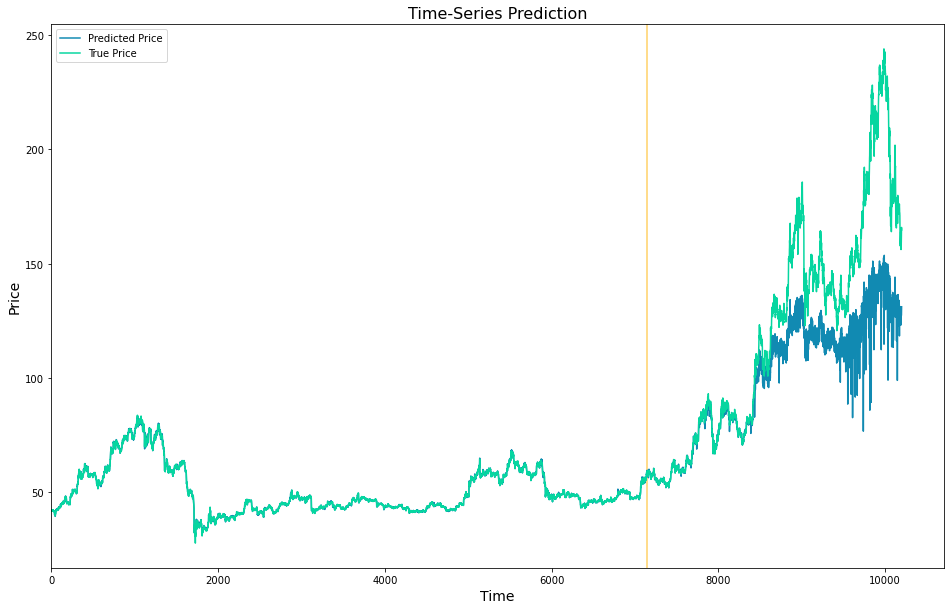

ripplehourly.csv
Epoch: 0, loss: 0.00368
Epoch: 100, loss: 0.00021
Epoch: 200, loss: 0.00007
Epoch: 300, loss: 0.00003
Epoch: 400, loss: 0.00002
Epoch: 500, loss: 0.00001
Epoch: 600, loss: 0.00001
Epoch: 700, loss: 0.00001
Epoch: 800, loss: 0.00001
Epoch: 900, loss: 0.00001
% positive:  0.48905586409670043
% negative:  0.5109441359032996
% neutral:  0.0
positive correct:  0.7334669338677354
negative correct:  0.7167519181585678
neutral prediction:  0.0006533812479581836
0.7249264946096047
   priceUsd  sentiment_positive_reddit  sentiment_positive_twitter  \
0  0.193772                   0.000000                    1.602088   
1  0.193341                   1.645721                    2.404690   
2  0.192906                   0.000000                    4.009241   
3  0.192935                   0.000000                    0.000000   
4  0.193849                   1.599421                    2.452598   

   sentiment_negative_reddit  sentiment_negative_twitter  \
0                   0.000

<Figure size 432x288 with 0 Axes>

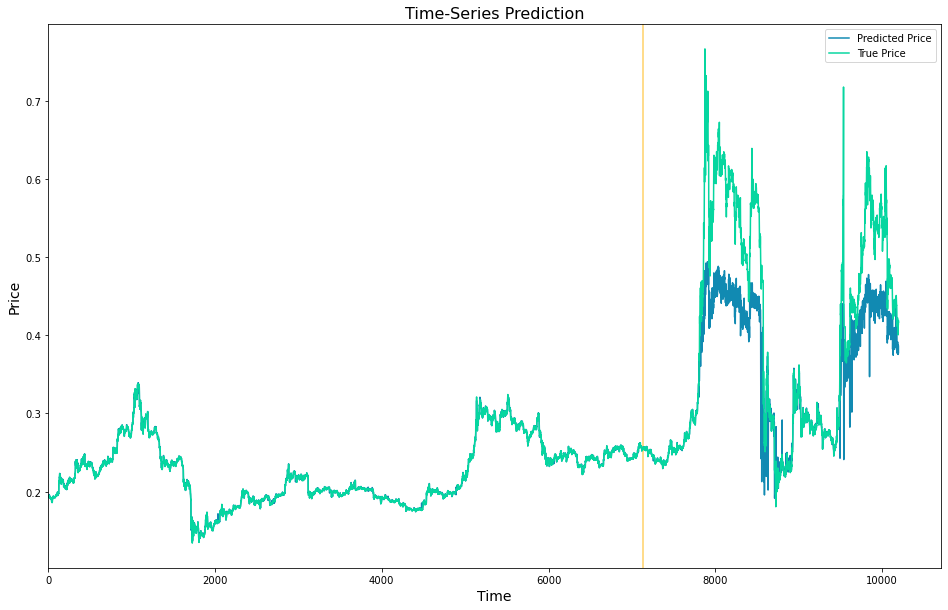

stellarhourly.csv
Epoch: 0, loss: 0.00272
Epoch: 100, loss: 0.00053
Epoch: 200, loss: 0.00005
Epoch: 300, loss: 0.00002
Epoch: 400, loss: 0.00001
Epoch: 500, loss: 0.00001
Epoch: 600, loss: 0.00000
Epoch: 700, loss: 0.00000
Epoch: 800, loss: 0.00000
Epoch: 900, loss: 0.00000
% positive:  0.4884024828487422
% negative:  0.5115975171512578
% neutral:  0.0
positive correct:  0.5966555183946488
negative correct:  0.5900383141762452
neutral prediction:  0.0006533812479581836
0.5932701731460307
   priceUsd  sentiment_positive_reddit  sentiment_positive_twitter  \
0  0.044508                        0.0                     0.00000   
1  0.045495                        0.0                     0.72245   
2  0.045474                        0.0                     0.00000   
3  0.044564                        0.0                     0.00000   
4  0.045335                        0.0                     0.00000   

   sentiment_negative_reddit  sentiment_negative_twitter  \
0                        

<Figure size 432x288 with 0 Axes>

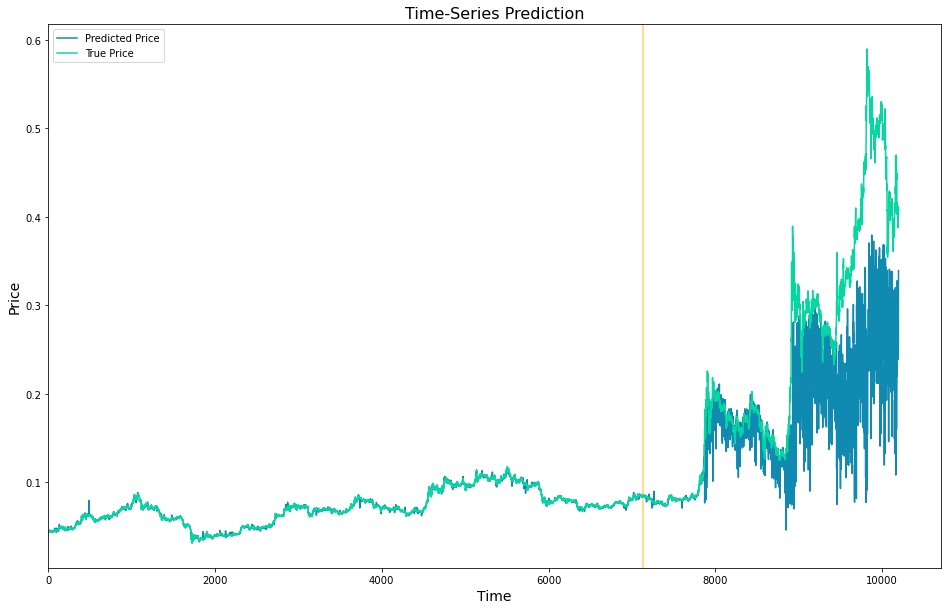

<Figure size 432x288 with 0 Axes>

In [13]:
dir_path = "datatest/"
file_list = [f for f in listdir(dir_path) if isfile(join(dir_path, f))]
#file_list = [f for f in listdir() if isfile(f)]

file_endings = ["5m.csv", "hourly.csv", "daily.csv"]

# FIXME: move to each fileending?
# im going to start with just 5m
file_ending = file_endings[1]
results = []
for filename in [name for name in file_list if file_ending in name]:
  crypto_name = filename.replace(file_ending, "")
  print(filename)
  
  df = pd.read_csv(dir_path + filename)
  # remove unused columns
  #exclude_cols = [1]
  #df = df.iloc[:, ~df.columns.isin(df.columns[exclude_cols])]

  # define LSTM class
  lstm = LSTMCustom(num_classes, input_size, hidden_size, num_layers, df.shape[1]) 
  optimizer = torch.optim.Adam(lstm.parameters(), lr=learning_rate) 

  lstm, cutoff = train(df, lstm)

  df_x_ss = ss.transform(df.iloc[:, 0:-1]) #old transformers
  df_y_mm = mm.transform(df.iloc[:, 0:1]) #old transformers

  df_x_ss = Variable(torch.Tensor(df_x_ss)) #converting to Tensors
  df_y_mm = Variable(torch.Tensor(df_y_mm))
  #reshaping the dataset
  df_x_ss = torch.reshape(df_x_ss, (df_x_ss.shape[0], 1, df_x_ss.shape[1]))

  train_predict = lstm(df_x_ss) #forward pass
  data_predict = train_predict.data.numpy() #numpy conversion
  
  dataY_plot = df_y_mm.data.numpy()

  data_predict = mm.inverse_transform(data_predict) #reverse transformation
  #print(df.iloc[cutoff:].priceDirection.reset_index(drop=True))
  accuracy = classify(data_predict[cutoff:], df.iloc[cutoff:].priceDirection.reset_index(drop=True))
  print(accuracy)
  print(df.head())
  dataY_plot = mm.inverse_transform(dataY_plot)

  plot_name = f"{crypto_name}.png"
  plot_time_series(data_predict, dataY_plot, cutoff, plot_name)

  model_name = f"{crypto_name}.pth"
  torch.save(lstm.state_dict(), model_name)

  results.append([filename, num_epochs, learning_rate, accuracy])

In [14]:
print(results)

[['binance-coinhourly.csv', 1000, 0.001, 0.6886638353479255], ['bitcoin-cashhourly.csv', 1000, 0.001, 0.7775236850702385], ['bitcoinhourly.csv', 1000, 0.001, 0.5021234890558641], ['cardanohourly.csv', 1000, 0.001, 0.6661221822933682], ['chainlinkhourly.csv', 1000, 0.001, 0.736687357072852], ['ethereumhourly.csv', 1000, 0.001, 0.5524338451486442], ['litecoinhourly.csv', 1000, 0.001, 0.6664488729173472], ['ripplehourly.csv', 1000, 0.001, 0.7249264946096047], ['stellarhourly.csv', 1000, 0.001, 0.5932701731460307]]


In [15]:
resultsdf = pd.DataFrame(results)

In [16]:
print(resultsdf)

                        0     1      2         3
0  binance-coinhourly.csv  1000  0.001  0.688664
1  bitcoin-cashhourly.csv  1000  0.001  0.777524
2       bitcoinhourly.csv  1000  0.001  0.502123
3       cardanohourly.csv  1000  0.001  0.666122
4     chainlinkhourly.csv  1000  0.001  0.736687
5      ethereumhourly.csv  1000  0.001  0.552434
6      litecoinhourly.csv  1000  0.001  0.666449
7        ripplehourly.csv  1000  0.001  0.724926
8       stellarhourly.csv  1000  0.001  0.593270
